# IT25103996 — Gunasekara K. J. W.
## Individual Preprocessing Task: Normalization / Scaling
**Dataset:** Chronic Kidney Disease (UCI ML Repository, id 336)
**Group:** 2026-Y2-S1-KU-56

This notebook demonstrates my individually assigned preprocessing technique — **feature scaling** —
applied to the numeric clinical features of the CKD dataset (building on `IT25103995_outliers_treated.csv`
from Samarakoon's notebook).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_style('whitegrid')
df = pd.read_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103996_scaled.csv')
numeric_cols = ['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wbcc','rbcc']
df[numeric_cols].describe().T[['min','max','mean','std']]

,min,max,mean,std
age,9.00,90.000,51.577694,16.733958
bp,55.00,95.000,75.839599,10.981224
bgr,27.50,223.500,134.078947,46.130380
bu,1.50,115.750,50.469799,30.716265
sc,0.40,5.525,2.082895,1.648845
sod,126.00,150.000,138.203008,5.272131
pot,2.80,6.000,4.384962,0.634537
hemo,5.15,17.800,12.539348,2.700729
pcv,19.00,54.000,39.127820,7.984671
wbcc,3350.00,12950.000,8160.526316,2022.443662


### Why this technique is needed for this dataset
The numeric features in this dataset are on very different scales — e.g. `wbcc` (white blood cell count)
ranges into the thousands while `pot` (potassium) ranges roughly 2.5-7.5. Distance-based algorithms (SVM
with RBF kernel, k-NN) and gradient-based algorithms (Neural Networks) are sensitive to feature scale: a
feature like `wbcc` would dominate the distance calculation purely because of its larger numeric range,
not because it is more informative. Scaling puts every feature on a comparable footing.

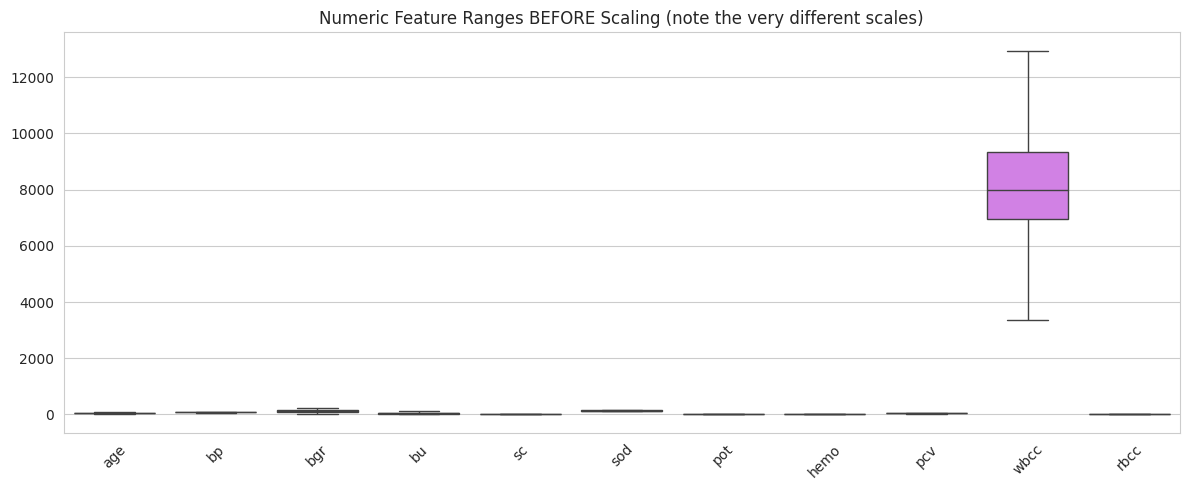

In [ ]:
# EDA Visualization 1: compare the scale/range of features before scaling
plt.figure(figsize=(12,5))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title('Numeric Feature Ranges BEFORE Scaling (note the very different scales)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103996_ranges_before_scaling.png', dpi=120)
plt.show()

**Interpretation:** `wbcc` visually flattens every other feature on the same axis because its scale
(thousands) is orders of magnitude larger than features like `pot` or `sc`. This confirms scaling is
necessary before feeding these features into any distance-based model.

In [ ]:
df_scaled = df.copy()

standard_scaler = StandardScaler()
df_scaled[numeric_cols] = standard_scaler.fit_transform(df[numeric_cols])

minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df[numeric_cols])

print("StandardScaler result (mean~0, std~1):")
print(df_scaled[numeric_cols].agg(['mean','std']).round(2))
print("\nMinMaxScaler result (range 0-1):")
print(df_minmax[numeric_cols].agg(['min','max']).round(2))

StandardScaler result (mean~0, std~1):
      age   bp  bgr   bu   sc  sod  pot  hemo  pcv  wbcc  rbcc
mean  0.0 -0.0  0.0  0.0  0.0 -0.0  0.0   0.0 -0.0   0.0   0.0
std   1.0  1.0  1.0  1.0  1.0  1.0  1.0   1.0  1.0   1.0   1.0

MinMaxScaler result (range 0-1):
     age   bp  bgr   bu   sc  sod  pot  hemo  pcv  wbcc  rbcc
min  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0   0.0   0.0
max  1.0  1.0  1.0  1.0  1.0  1.0  1.0   1.0  1.0   1.0   1.0


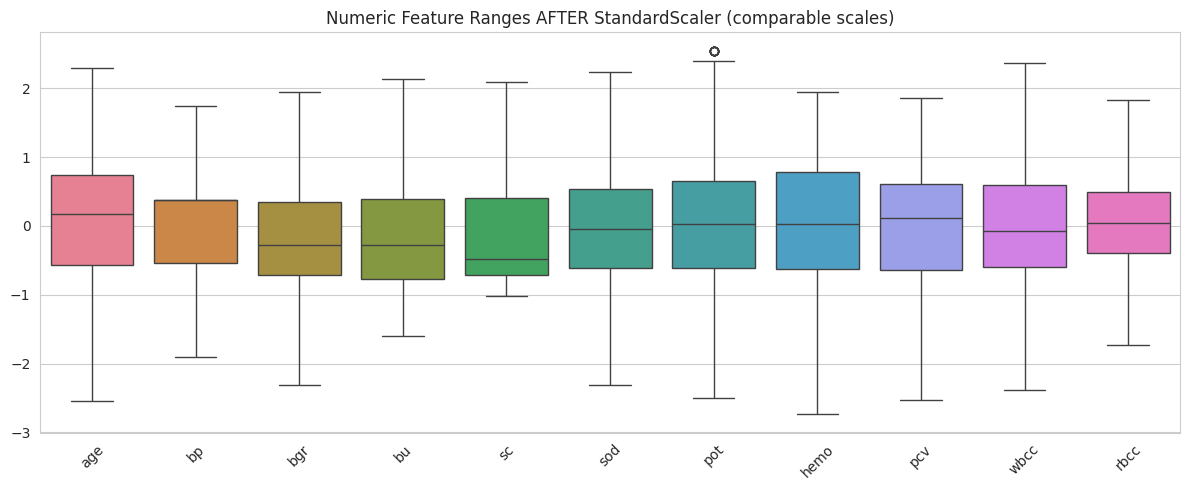

In [ ]:
# EDA Visualization 2: same features after StandardScaler, now on a comparable scale
plt.figure(figsize=(12,5))
sns.boxplot(data=df_scaled[numeric_cols])
plt.xticks(rotation=45)
plt.title('Numeric Feature Ranges AFTER StandardScaler (comparable scales)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103996_ranges_after_scaling.png', dpi=120)
plt.show()

**Interpretation:** After StandardScaler, every numeric feature is centered around 0 with unit
variance, so no single feature can dominate a distance or gradient calculation purely due to its raw scale.
We chose **StandardScaler** (rather than Min-Max) as the pipeline's default because the data still contains
mild skew even after capping, and StandardScaler is less sensitive than Min-Max to the exact position of the
remaining extreme values.

In [ ]:
df_scaled.to_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103996_scaled.csv', index=False)
print("Saved scaled dataset for downstream use by the group pipeline.")

Saved scaled dataset for downstream use by the group pipeline.


### Summary
- **Technique:** Feature scaling — compared **StandardScaler** (z-score) and **MinMaxScaler** (0-1
  normalization); StandardScaler selected as the pipeline default.
- **Justification:** The 11 numeric clinical features span very different ranges (e.g. `wbcc` in the
  thousands vs `pot` under 10); without scaling, distance/gradient-based algorithms (SVM, Neural Networks)
  would be biased toward large-range features regardless of their true predictive value.
- **Output:** `results/outputs/IT25103996_scaled.csv` — numeric features standardized to mean 0, std 1.